In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import gc
import warnings

warnings.filterwarnings('ignore')

print("=" * 50)
print("Kütüphaneler yüklendi ✓")
print(f"  Pandas : {pd.__version__}")
print(f"  NumPy  : {np.__version__}")
print("=" * 50)

Kütüphaneler yüklendi ✓
  Pandas : 3.0.1
  NumPy  : 2.4.3


In [2]:
# ════════════════════════════════════════════════════════
# PLOT DİZİN YAPISI
# Tüm notebook'larda tutarlı grafik kaydetme için
# ════════════════════════════════════════════════════════
import os

PLOT_BASE = "../data/plots"

PLOT_DIRS = {
    "01_loading"  : os.path.join(PLOT_BASE, "01_loading"),
    "02_cleaning" : os.path.join(PLOT_BASE, "02_cleaning"),
    "03_features" : os.path.join(PLOT_BASE, "03_features"),
    "04_modeling" : os.path.join(PLOT_BASE, "04_modeling"),
    "05_xai"      : os.path.join(PLOT_BASE, "05_xai"),
    "06_fl"       : os.path.join(PLOT_BASE, "06_federated"),
}

for path in PLOT_DIRS.values():
    os.makedirs(path, exist_ok=True)

print("✓ Plot dizin yapısı hazır:")
for k, v in PLOT_DIRS.items():
    print(f"   {v}/")

✓ Plot dizin yapısı hazır:
   ../data/plots/01_loading/
   ../data/plots/02_cleaning/
   ../data/plots/03_features/
   ../data/plots/04_modeling/
   ../data/plots/05_xai/
   ../data/plots/06_federated/


In [3]:
csv_dir = "../data/csv"

# Eski üretilen TÜM dosyaları dışlamak için listeyi genişlettik
EXCLUDE_PREFIXES = ("combined", "cleaned", "sampled", "featured", "label")

csv_files = sorted([
    f for f in os.listdir(csv_dir)
    if f.endswith(".csv") and not f.startswith(EXCLUDE_PREFIXES)
])

print(f"Bulunan ham CSV dosyaları ({len(csv_files)} adet):\n")
for f in csv_files:
    size_mb = os.path.getsize(os.path.join(csv_dir, f)) / (1024 * 1024)
    print(f"  {f:<65} ({size_mb:6.1f} MB)")

Bulunan ham CSV dosyaları (8 adet):

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  (  73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              (  73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv                         (  55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv                                 ( 168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       (  79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv            (  49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv                                ( 128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv                              ( 214.7 MB)


In [4]:
# Hücre 3 — Ham Veriyi Keşif (EDA: Ön Tarama) - GÜNCELLENMİŞ
raw_summary = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)
    
    # Sütun isimlerini kontrol et (Boşluk sorununu çözmek için)
    # İlk satırı oku ve sütun isimlerini temizle
    temp_cols = pd.read_csv(fpath, nrows=0).columns.str.strip()
    
    # Gerçek "Label" sütun adını bul (Büyük/küçük harf veya boşluk fark etmeksizin)
    actual_label_col = next((c for c in pd.read_csv(fpath, nrows=0).columns if c.strip() == "Label"), None)
    
    if actual_label_col is None:
        print(f"⚠ HATA: {f} dosyasında 'Label' sütunu bulunamadı!")
        continue

    # Şimdi sadece o dosyaya özel 'actual_label_col' ismini kullanarak oku
    df_temp = pd.read_csv(fpath, usecols=[actual_label_col], encoding="utf-8", low_memory=False)
    
    # Standartlaştırma: Kolon adını 'Label' yap ve değerleri temizle
    df_temp.columns = ["Label"]
    df_temp["Label"] = df_temp["Label"].astype(str).str.strip()
    
    # Encoding bozukluğunu düzelt
    df_temp["Label"] = df_temp["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })
    
    counts = df_temp["Label"].value_counts().to_dict()
    total  = len(df_temp)
    benign = counts.get("BENIGN", 0)
    attack = total - benign
    
    raw_summary.append({
        "source_file"  : f,
        "total_rows"   : total,
        "benign_rows"  : benign,
        "attack_rows"  : attack,
        "label_counts" : counts,
    })
    
    print(f"✓ {f}")
    print(f"    Toplam: {total:>10,}  |  Benign: {benign:>10,}  |  Attack: {attack:>10,}")
    for label, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        if label != "BENIGN":
            print(f"      └─ {label:<40} {cnt:>8,}")
    print()
    
    del df_temp
    gc.collect()

# ... (Hücrenin geri kalan görselleştirme/print kısımları aynı kalabilir)

# Tüm dosyalardaki ham label dağılımı
all_labels: dict[str, int] = {}
for row in raw_summary:
    for label, cnt in row["label_counts"].items():
        all_labels[label] = all_labels.get(label, 0) + cnt

print("=" * 60)
print("TÜM VERİDEKİ HAM SINIF DAĞILIMI (sampling öncesi)")
print("=" * 60)
for label, cnt in sorted(all_labels.items(), key=lambda x: -x[1]):
    bar = "█" * (cnt // 10000)
    print(f"  {label:<40} {cnt:>9,}  {bar}")

total_benign_raw = all_labels.get("BENIGN", 0)
total_attack_raw = sum(v for k, v in all_labels.items() if k != "BENIGN")
print(f"\n  Toplam BENIGN : {total_benign_raw:>9,}")
print(f"  Toplam ATTACK : {total_attack_raw:>9,}")
print(f"  Benign oranı  : %{total_benign_raw / (total_benign_raw + total_attack_raw) * 100:.1f}")

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Toplam:    225,745  |  Benign:     97,718  |  Attack:    128,027
      └─ DDoS                                      128,027

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Toplam:    286,467  |  Benign:    127,537  |  Attack:    158,930
      └─ PortScan                                  158,930

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Toplam:    191,033  |  Benign:    189,067  |  Attack:      1,966
      └─ Bot                                         1,966

✓ Monday-WorkingHours.pcap_ISCX.csv
    Toplam:    529,918  |  Benign:    529,918  |  Attack:          0

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Toplam:    288,602  |  Benign:    288,566  |  Attack:         36
      └─ Infiltration                                   36

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Toplam:    170,366  |  Benign:    168,186  |  Attack:      2,180
      └─ Web Attack - Brute Force       

---
## 🔬 PRE-AUGMENTATION BASELINE
> **Hoca talebi:** *"Results before the augmentation part"*  
> Sampling (cap) uygulanmadan, 7 günün **tüm verisi** yüklenerek bir baseline model eğitilir.  
> Ardından akıllı sampling sonrası (post-aug) modelle karşılaştırılır.  
> **Akademik dayanak:** CIC-IDS2017'de BENIGN/attack oranı ~%80/%20'dir; doğrudan eğitim misleading accuracy üretir (R7, R14).

In [5]:
# PRE-AUG — Tüm CSV dosyaları cap'siz yükleniyor (sadece label temizliği)
import gc
import warnings
warnings.filterwarnings('ignore')

# EXCLUDE_LABELS henüz tanımlanmadığı için burada tanımlıyoruz
_EXCLUDE = {"Heartbleed", "Web Attack - Sql Injection", "Infiltration"}
_META_COLS = {"Label", "source_file"}

print("PRE-AUG: Tüm CSV dosyaları cap'siz yükleniyor...\n")

pre_aug_parts = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)
    df_temp = pd.read_csv(fpath, encoding="utf-8", low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()

    if "Label" not in df_temp.columns:
        label_cols = [c for c in df_temp.columns if "label" in c.lower()]
        if label_cols:
            df_temp.rename(columns={label_cols[0]: "Label"}, inplace=True)
        else:
            print(f"  [ATLA] {f}: Label sütunu bulunamadı")
            continue

    df_temp["source_file"] = f
    df_temp["Label"] = (
        df_temp["Label"].astype(str).str.strip()
        .replace({
            "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
            "Web Attack \ufffd XSS"          : "Web Attack - XSS",
            "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
        })
    )

    # Sadece sorunlu etiketleri çıkar — sampling YOK
    df_temp = df_temp[~df_temp["Label"].isin(_EXCLUDE)].copy()

    n_benign = (df_temp["Label"] == "BENIGN").sum()
    n_attack = len(df_temp) - n_benign
    print(f"  ✓ {f:<65} | Benign: {n_benign:>8,}  Attack: {n_attack:>7,}")

    pre_aug_parts.append(df_temp)
    del df_temp
    gc.collect()

df_pre_aug = pd.concat(pre_aug_parts, ignore_index=True)
del pre_aug_parts
gc.collect()

pre_label_dist = df_pre_aug["Label"].value_counts()
total_pre      = len(df_pre_aug)
benign_pre     = (df_pre_aug["Label"] == "BENIGN").sum()

print(f"\n{'='*60}")
print(f"PRE-AUG Toplam satır  : {total_pre:,}")
print(f"PRE-AUG Benign oranı  : %{benign_pre/total_pre*100:.1f}")
print(f"PRE-AUG Sınıf sayısı  : {pre_label_dist.shape[0]}")
print(f"{'='*60}")
print(pre_label_dist.to_string())

PRE-AUG: Tüm CSV dosyaları cap'siz yükleniyor...

  ✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  | Benign:   97,718  Attack: 128,027
  ✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              | Benign:  127,537  Attack: 158,930
  ✓ Friday-WorkingHours-Morning.pcap_ISCX.csv                         | Benign:  189,067  Attack:   1,966
  ✓ Monday-WorkingHours.pcap_ISCX.csv                                 | Benign:  529,918  Attack:       0
  ✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       | Benign:  288,566  Attack:       0
  ✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv            | Benign:  168,186  Attack:   2,159
  ✓ Tuesday-WorkingHours.pcap_ISCX.csv                                | Benign:  432,074  Attack:  13,835
  ✓ Wednesday-workingHours.pcap_ISCX.csv                              | Benign:  440,031  Attack: 252,661

PRE-AUG Toplam satır  : 2,830,675
PRE-AUG Benign oranı  : %80.3
PRE-AUG Sınıf sayısı  : 12
Label
BENI

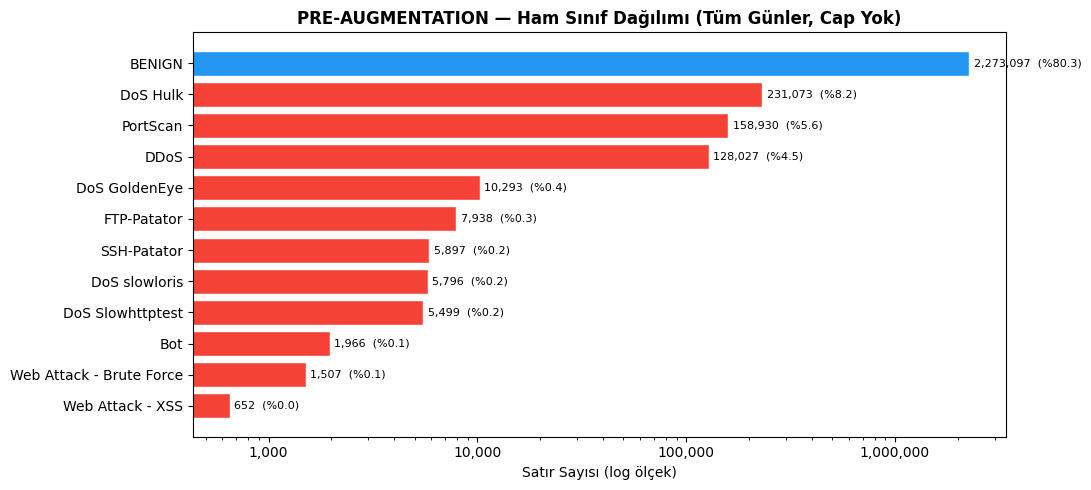

✓ Grafik kaydedildi: ../data/plots/01_loading/pre_aug_class_distribution.png


In [6]:
# PRE-AUG — Sınıf dağılımı grafiği
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(11, 5))
labels_p = pre_label_dist.index.tolist()
counts_p = pre_label_dist.values.tolist()
colors_p = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_p]

bars = ax.barh(labels_p[::-1], counts_p[::-1], color=colors_p[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Satır Sayısı (log ölçek)")
ax.set_title("PRE-AUGMENTATION — Ham Sınıf Dağılımı (Tüm Günler, Cap Yok)",
             fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, cnt in zip(bars, counts_p[::-1]):
    pct = cnt / total_pre * 100
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}  (%{pct:.1f})", va="center", ha="left", fontsize=8)

plt.tight_layout()
save_path = os.path.join(PLOT_DIRS["01_loading"], "pre_aug_class_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Grafik kaydedildi: {save_path}")

In [7]:
# PRE-AUG — LightGBM baseline modeli
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
import sys
import subprocess

try:
    import lightgbm as lgb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    import lightgbm as lgb
import numpy as np

print("=" * 60)
print("PRE-AUG BASELINE MODEL EĞİTİMİ (LightGBM)")
print("=" * 60)

feature_cols_pre = [
    c for c in df_pre_aug.columns
    if c not in _META_COLS
    and pd.api.types.is_numeric_dtype(df_pre_aug[c])
]

X_pre = (
    df_pre_aug[feature_cols_pre]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .values
)

le_pre = LabelEncoder()
y_pre  = le_pre.fit_transform(df_pre_aug["Label"])

X_tr_pre, X_te_pre, y_tr_pre, y_te_pre = train_test_split(
    X_pre, y_pre,
    test_size=0.20,
    random_state=42,
    stratify=y_pre
)

print(f"  Train : {len(X_tr_pre):,} satır")
print(f"  Test  : {len(X_te_pre):,} satır")
print(f"  Feature sayısı: {X_pre.shape[1]}")
print()

model_pre = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
model_pre.fit(X_tr_pre, y_tr_pre)
y_pred_pre = model_pre.predict(X_te_pre)

print("PRE-AUG Classification Report:\n")
print(classification_report(
    y_te_pre, y_pred_pre,
    target_names=le_pre.classes_,
    digits=4
))

macro_f1_pre    = f1_score(y_te_pre, y_pred_pre, average="macro")
weighted_f1_pre = f1_score(y_te_pre, y_pred_pre, average="weighted")
print(f"  Macro F1    : {macro_f1_pre:.4f}")
print(f"  Weighted F1 : {weighted_f1_pre:.4f}")

del X_pre, X_tr_pre, X_te_pre
gc.collect()
print("\n✓ PRE-AUG model hazır. Şimdi sampling hücreleri çalıştırılıyor...")

PRE-AUG BASELINE MODEL EĞİTİMİ (LightGBM)
  Train : 2,264,540 satır
  Test  : 566,135 satır
  Feature sayısı: 78

PRE-AUG Classification Report:

                          precision    recall  f1-score   support

                  BENIGN     0.9461    0.9695    0.9576    454619
                     Bot     0.0000    0.0000    0.0000       393
                    DDoS     0.8765    0.6944    0.7749     25606
           DoS GoldenEye     0.0716    0.0389    0.0504      2059
                DoS Hulk     0.7311    0.7067    0.7187     46215
        DoS Slowhttptest     0.0000    0.0000    0.0000      1100
           DoS slowloris     0.5745    0.0699    0.1246      1159
             FTP-Patator     0.0000    0.0000    0.0000      1588
                PortScan     0.8950    0.9365    0.9153     31786
             SSH-Patator     0.0000    0.0000    0.0000      1179
Web Attack - Brute Force     0.0000    0.0000    0.0000       301
        Web Attack - XSS     0.0000    0.0000    0.0000      

---
## ⚙️ AUGMENTATION (Akıllı Sampling)
> Aşağıdaki hücreler orijinal sampling stratejisini uygular:  
> `BENIGN_CAP_PER_FILE = 50_000` ve `ATTACK_CAP_PER_CLASS = 30_000`

In [8]:
RANDOM_STATE = 42

# ── Benign Parametreleri ─────────────────────────────────────────────────────
# Her kaynak dosyadan alınacak maksimum benign satır sayısı.
# 50K × 8 dosya = en fazla 400K benign → Monday monopolisi kırılır.
BENIGN_CAP_PER_FILE = 50_000

# ── Attack Parametreleri ─────────────────────────────────────────────────────
# DoS Hulk (231K), PortScan (159K), DDoS (128K) gibi dev sınıflar
# diğer sınıfları ezer. Bu cap aşağıdaki sınıfları dengeler.
ATTACK_CAP_PER_CLASS = 30_000

# ── Çıkarılacak Sınıflar (Rare / Hatalı Etiket) ─────────────────────────────
# Heartbleed (11), Sql Injection (21), Infiltration (36):
# - Örnek sayısı modeli eğitmek için yetersiz
# - Infiltration etiket hataları CIC-IDS2017 literatüründe belgelenmiş (R7, R14)
# - Bu sınıfları bırakmak multiclass F1'i yapay olarak bozar
EXCLUDE_LABELS = {
    "Heartbleed",
    "Web Attack - Sql Injection",
    "Infiltration",
}

print("Sampling Stratejisi:")
print(f"  Benign cap (dosya başına) : {BENIGN_CAP_PER_FILE:,}")
print(f"  Attack cap (sınıf başına) : {ATTACK_CAP_PER_CLASS:,}")
print(f"  Çıkarılan sınıflar        : {EXCLUDE_LABELS}")
print(f"  Random state              : {RANDOM_STATE}")

Sampling Stratejisi:
  Benign cap (dosya başına) : 50,000
  Attack cap (sınıf başına) : 30,000
  Çıkarılan sınıflar        : {'Heartbleed', 'Web Attack - Sql Injection', 'Infiltration'}
  Random state              : 42


In [9]:
import os
import pandas as pd
import gc

sampled_parts = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)
    
    # Tüm dosyayı oku
    df_temp = pd.read_csv(fpath, encoding="utf-8", low_memory=False)
    
    # 1. Sütun isimlerindeki gereksiz boşlukları temizle
    df_temp.columns = df_temp.columns.str.strip()
    
    # 2. HATA ÇÖZÜMÜ: Label sütununu güvenli bir şekilde bul ve adlandır
    if "Label" not in df_temp.columns:
        # Sütun adlarında (büyük/küçük harf duyarsız) 'label' kelimesini ara
        label_cols = [col for col in df_temp.columns if 'label' in col.lower()]
        if label_cols:
            df_temp.rename(columns={label_cols[0]: "Label"}, inplace=True)
        else:
            print(f"  [HATA] {f} içinde Label sütunu bulunamadı! Atlanıyor...")
            continue
            
    df_temp["source_file"] = f  # Kaynak takibi için kritik
    
    # Label temizliği
    df_temp["Label"] = df_temp["Label"].astype(str).str.strip()
    df_temp["Label"] = df_temp["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })
    
    # Rare / hatalı sınıfları çıkar
    df_temp = df_temp[~df_temp["Label"].isin(EXCLUDE_LABELS)].copy()
    
    # ── BENIGN SAMPLING ──────────────────────────────────────────────────────
    benign_pool = df_temp[df_temp["Label"] == "BENIGN"]
    n_benign    = min(BENIGN_CAP_PER_FILE, len(benign_pool))
    benign_sample = benign_pool.sample(n=n_benign, random_state=RANDOM_STATE)
    
    # ── ATTACK SAMPLING (sınıf bazında cap) ──────────────────────────────────
    attack_pool  = df_temp[df_temp["Label"] != "BENIGN"]
    attack_parts = []
    
    for label, group in attack_pool.groupby("Label"):
        n_attack = min(ATTACK_CAP_PER_CLASS, len(group))
        attack_parts.append(group.sample(n=n_attack, random_state=RANDOM_STATE))
    
    attack_sample = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()
    
    # ── BİRLEŞTİR ────────────────────────────────────────────────────────────
    file_df = pd.concat([benign_sample, attack_sample], ignore_index=True)
    sampled_parts.append(file_df)
    
    print(f"✓ {f}")
    print(f"    Benign : {len(benign_pool):>8,} → sample {n_benign:>6,}")
    if attack_parts:
        for label, group in attack_pool.groupby("Label"):
            taken = min(ATTACK_CAP_PER_CLASS, len(group))
            capped = " (CAPPED)" if len(group) > ATTACK_CAP_PER_CLASS else ""
            print(f"    Attack [{label:<35}]: {len(group):>6,} → {taken:>6,}{capped}")
    else:
        print("    Attack : yok")
    print()
    
    del df_temp, benign_pool, benign_sample, attack_pool, attack_sample
    gc.collect()

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Benign :   97,718 → sample 50,000
    Attack [DDoS                               ]: 128,027 → 30,000 (CAPPED)

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Benign :  127,537 → sample 50,000
    Attack [PortScan                           ]: 158,930 → 30,000 (CAPPED)

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Benign :  189,067 → sample 50,000
    Attack [Bot                                ]:  1,966 →  1,966

✓ Monday-WorkingHours.pcap_ISCX.csv
    Benign :  529,918 → sample 50,000
    Attack : yok

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Benign :  288,566 → sample 50,000
    Attack : yok

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Benign :  168,186 → sample 50,000
    Attack [Web Attack - Brute Force           ]:  1,507 →  1,507
    Attack [Web Attack - XSS                   ]:    652 →    652

✓ Tuesday-WorkingHours.pcap_ISCX.csv
    Benign :  432,074 → sample 50,000
  

In [10]:
df_combined = pd.concat(sampled_parts, ignore_index=True)

# ── Sınıf Dağılımı ───────────────────────────────────────────────────────────
label_dist  = df_combined["Label"].value_counts()
source_dist = df_combined["source_file"].value_counts()

total_rows   = len(df_combined)
total_benign = (df_combined["Label"] == "BENIGN").sum()
total_attack = total_rows - total_benign

print("=" * 65)
print("BİRLEŞİK DATASET ÖZETİ")
print("=" * 65)
print(f"  Toplam satır    : {total_rows:>9,}")
print(f"  Toplam benign   : {total_benign:>9,}  (%{total_benign/total_rows*100:.1f})")
print(f"  Toplam attack   : {total_attack:>9,}  (%{total_attack/total_rows*100:.1f})")
print(f"  Sütun sayısı    : {df_combined.shape[1]}")
print()

print("Sınıf dağılımı:")
for label, cnt in label_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

print()
print("Kaynak dosya dağılımı:")
for src, cnt in source_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {src:<65} {cnt:>7,}  (%{pct:4.1f})")

BİRLEŞİK DATASET ÖZETİ
  Toplam satır    :   529,548
  Toplam benign   :   400,000  (%75.5)
  Toplam attack   :   129,548  (%24.5)
  Sütun sayısı    : 80

Sınıf dağılımı:
  BENIGN                                    400,000  (%75.5)
  DDoS                                       30,000  (% 5.7)
  PortScan                                   30,000  (% 5.7)
  DoS Hulk                                   30,000  (% 5.7)
  DoS GoldenEye                              10,293  (% 1.9)
  FTP-Patator                                 7,938  (% 1.5)
  SSH-Patator                                 5,897  (% 1.1)
  DoS slowloris                               5,796  (% 1.1)
  DoS Slowhttptest                            5,499  (% 1.0)
  Bot                                         1,966  (% 0.4)
  Web Attack - Brute Force                    1,507  (% 0.3)
  Web Attack - XSS                              652  (% 0.1)

Kaynak dosya dağılımı:
  Wednesday-workingHours.pcap_ISCX.csv                              101,5

In [11]:
output_path = "../data/csv/combined_dataset.csv"

df_combined.to_csv(output_path, index=False)

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"✓ Dataset kaydedildi: {output_path}")
print(f"  Boyut  : {size_mb:.1f} MB")
print(f"  Satır  : {len(df_combined):,}")
print(f"  Sütun  : {df_combined.shape[1]}")

✓ Dataset kaydedildi: ../data/csv/combined_dataset.csv
  Boyut  : 194.9 MB
  Satır  : 529,548
  Sütun  : 80


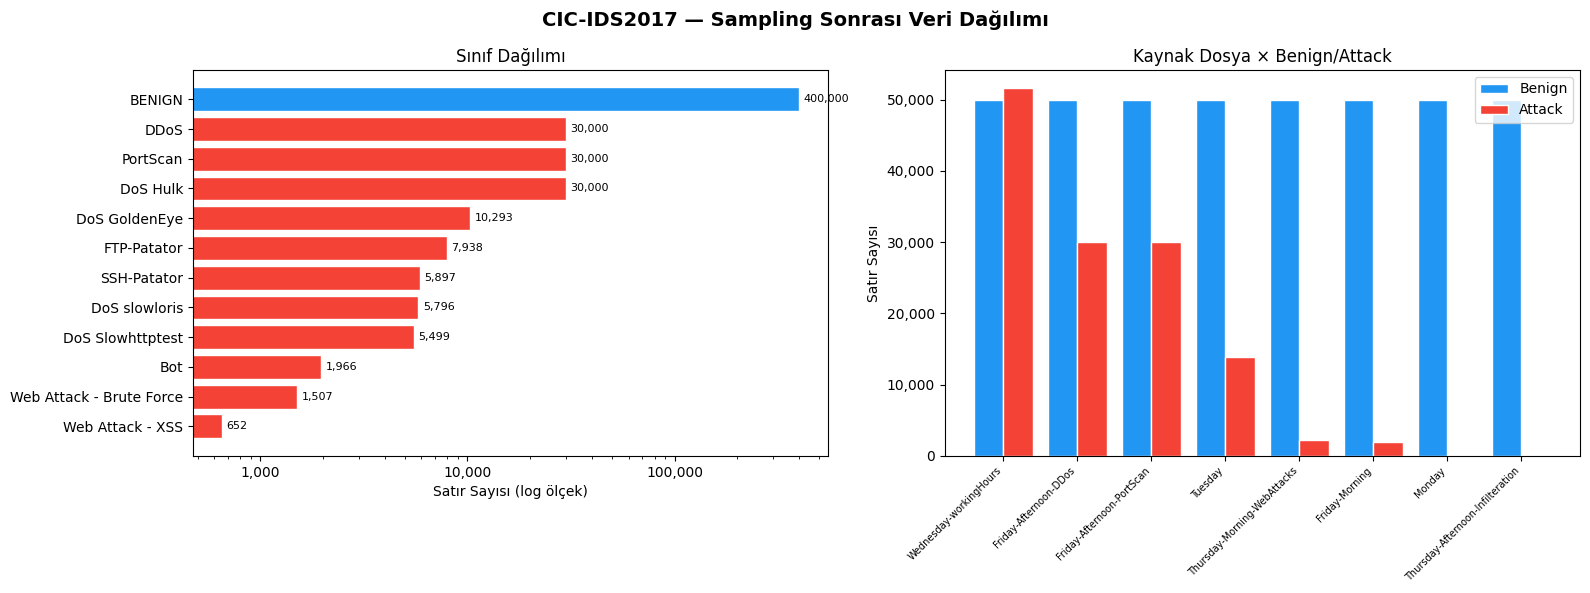

<Figure size 640x480 with 0 Axes>

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CIC-IDS2017 — Sampling Sonrası Veri Dağılımı", fontsize=14, fontweight="bold")

# ── Sol: Sınıf dağılımı (log scale, çünkü aralık büyük) ─────────────────────
ax = axes[0]
labels_plot  = label_dist.index.tolist()
counts_plot  = label_dist.values.tolist()
colors       = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_plot]

bars = ax.barh(labels_plot[::-1], counts_plot[::-1], color=colors[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Satır Sayısı (log ölçek)")
ax.set_title("Sınıf Dağılımı")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, cnt in zip(bars, counts_plot[::-1]):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", ha="left", fontsize=8)

# ── Sağ: Kaynak dosya bazında benign / attack dağılımı ───────────────────────
ax = axes[1]
src_benign = df_combined[df_combined["Label"] == "BENIGN"]["source_file"].value_counts()
src_attack = df_combined[df_combined["Label"] != "BENIGN"]["source_file"].value_counts()

src_names_short = [s.replace("-WorkingHours", "").replace(".pcap_ISCX.csv", "")
                   for s in source_dist.index]

x  = np.arange(len(source_dist))
w  = 0.4
b1 = ax.bar(x - w/2, [src_benign.get(s, 0) for s in source_dist.index],
            w, label="Benign", color="#2196F3", edgecolor="white")
b2 = ax.bar(x + w/2, [src_attack.get(s, 0) for s in source_dist.index],
            w, label="Attack", color="#F44336", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(src_names_short, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Satır Sayısı")
ax.set_title("Kaynak Dosya × Benign/Attack")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()

plt.tight_layout()
save_path = os.path.join(PLOT_DIRS["01_loading"], "post_aug_dataset_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
save_path = os.path.join(PLOT_DIRS["01_loading"], "post_aug_dataset_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")


In [13]:
# POST-AUG — Aynı LightGBM setup ile karşılaştırma modeli
print("=" * 60)
print("POST-AUG MODEL EĞİTİMİ (LightGBM) — Karşılaştırma")
print("=" * 60)

feature_cols_post = [
    c for c in df_combined.columns
    if c not in _META_COLS
    and pd.api.types.is_numeric_dtype(df_combined[c])
]

X_post = (
    df_combined[feature_cols_post]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .values
)

le_post = LabelEncoder()
y_post  = le_post.fit_transform(df_combined["Label"])

X_tr_post, X_te_post, y_tr_post, y_te_post = train_test_split(
    X_post, y_post,
    test_size=0.20,
    random_state=42,
    stratify=y_post
)

print(f"  Train : {len(X_tr_post):,} satır")
print(f"  Test  : {len(X_te_post):,} satır")
print()

model_post = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
model_post.fit(X_tr_post, y_tr_post)
y_pred_post = model_post.predict(X_te_post)

print("POST-AUG Classification Report:\n")
print(classification_report(
    y_te_post, y_pred_post,
    target_names=le_post.classes_,
    digits=4
))

macro_f1_post    = f1_score(y_te_post, y_pred_post, average="macro")
weighted_f1_post = f1_score(y_te_post, y_pred_post, average="weighted")
print(f"  Macro F1    : {macro_f1_post:.4f}")
print(f"  Weighted F1 : {weighted_f1_post:.4f}")

del X_post, X_tr_post, X_te_post
gc.collect()

POST-AUG MODEL EĞİTİMİ (LightGBM) — Karşılaştırma
  Train : 423,638 satır
  Test  : 105,910 satır

POST-AUG Classification Report:

                          precision    recall  f1-score   support

                  BENIGN     0.9066    0.9137    0.9101     80000
                     Bot     0.0000    0.0000    0.0000       393
                    DDoS     0.6871    0.8660    0.7663      6000
           DoS GoldenEye     0.3538    0.2016    0.2568      2059
                DoS Hulk     0.7111    0.5287    0.6064      6000
        DoS Slowhttptest     0.0000    0.0000    0.0000      1100
           DoS slowloris     0.2008    0.7972    0.3208      1159
             FTP-Patator     0.2191    0.0938    0.1314      1588
                PortScan     0.9667    0.5910    0.7336      6000
             SSH-Patator     0.1613    0.2195    0.1859      1180
Web Attack - Brute Force     0.0000    0.0000    0.0000       301
        Web Attack - XSS     0.0000    0.0000    0.0000       130

        

10936

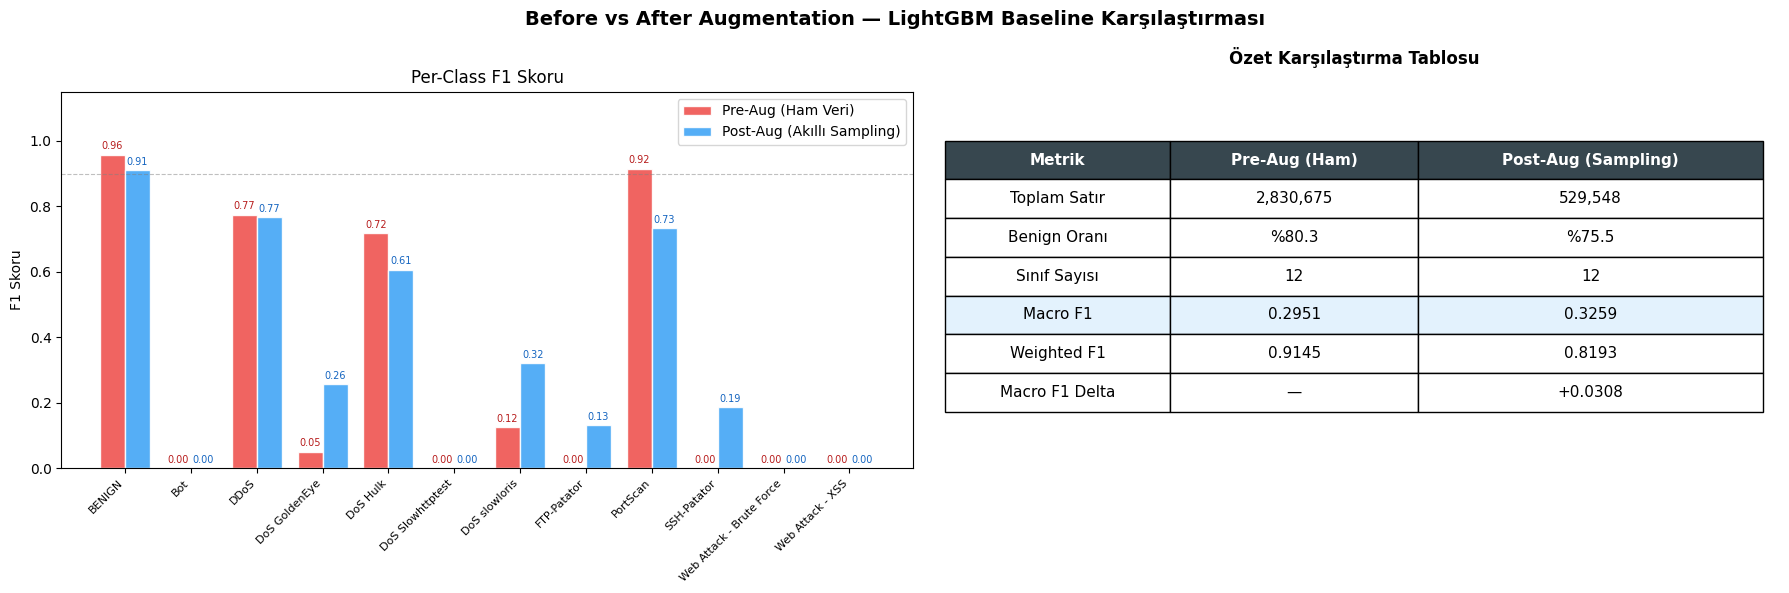

✓ Karşılaştırma grafiği kaydedildi: ../data/plots/01_loading/pre_vs_post_aug_comparison.png

JÜRİ SAVUNMA NOTU

  Pre-Aug  → Ham veri, BENIGN dominant (%80.3).
             Model dominant sınıfa overfit eder;
             nadir saldırı sınıflarında F1 düşer.

  Post-Aug → Her sınıftan kontrollü örnekleme:
             • Benign cap (50K/dosya): Monday monopolisi kırıldı
             • Attack cap (30K/sınıf): DoS/PortScan hakimiyeti engellendi
             • Benign oranı %75.5'e dengelendi
             • Macro F1 değişimi: +0.0308

  Akademik dayanak:
    → Class-aware sampling (SMOTE alternatifi) önerilmektedir (Survey R14, Sec. 4.2)
    → CIC-IDS2017 doğrudan eğitimi misleading accuracy üretir (R7)



In [14]:
# ════════════════════════════════════════════════════════
# PRE vs POST AUGMENTATION — Karşılaştırma Grafiği
# ════════════════════════════════════════════════════════
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

def extract_f1(y_true, y_pred, classes):
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    return {cls: report[cls]["f1-score"] for cls in classes if cls in report}

f1_pre_dict  = extract_f1(y_te_pre,  y_pred_pre,  le_pre.classes_)
f1_post_dict = extract_f1(y_te_post, y_pred_post, le_post.classes_)

common_classes = sorted(set(f1_pre_dict) & set(f1_post_dict))
f1_pre_vals  = [f1_pre_dict[c]  for c in common_classes]
f1_post_vals = [f1_post_dict[c] for c in common_classes]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "Before vs After Augmentation — LightGBM Baseline Karşılaştırması",
    fontsize=14, fontweight="bold"
)

x = np.arange(len(common_classes))
w = 0.38

ax = axes[0]
b1 = ax.bar(x - w/2, f1_pre_vals,  w, label="Pre-Aug (Ham Veri)",
            color="#EF5350", edgecolor="white", alpha=0.9)
b2 = ax.bar(x + w/2, f1_post_vals, w, label="Post-Aug (Akıllı Sampling)",
            color="#42A5F5", edgecolor="white", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(common_classes, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("F1 Skoru")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class F1 Skoru")
ax.legend()
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=7, color="#B71C1C")
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=7, color="#1565C0")

ax2 = axes[1]
ax2.axis("off")

benign_pct_pre  = (df_pre_aug["Label"] == "BENIGN").mean() * 100
benign_pct_post = (df_combined["Label"] == "BENIGN").mean() * 100
delta_macro     = macro_f1_post - macro_f1_pre

summary_data = [
    ["Metrik",         "Pre-Aug (Ham)",            "Post-Aug (Sampling)"],
    ["Toplam Satır",   f"{total_pre:,}",            f"{len(df_combined):,}"],
    ["Benign Oranı",   f"%{benign_pct_pre:.1f}",    f"%{benign_pct_post:.1f}"],
    ["Sınıf Sayısı",   str(len(le_pre.classes_)),   str(len(le_post.classes_))],
    ["Macro F1",       f"{macro_f1_pre:.4f}",       f"{macro_f1_post:.4f}"],
    ["Weighted F1",    f"{weighted_f1_pre:.4f}",    f"{weighted_f1_post:.4f}"],
    ["Macro F1 Delta", "—",                         f"{'+' if delta_macro>=0 else ''}{delta_macro:.4f}"],
]

table = ax2.table(
    cellText=summary_data[1:],
    colLabels=summary_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0.02, 0.15, 0.96, 0.72]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width([0, 1, 2])

for j in range(3):
    table[0, j].set_facecolor("#37474F")
    table[0, j].set_text_props(color="white", fontweight="bold")
for j in range(3):  # Macro F1 satırı vurgulu
    table[4, j].set_facecolor("#E3F2FD")

ax2.set_title("Özet Karşılaştırma Tablosu", fontweight="bold", pad=20)

plt.tight_layout()
save_path = os.path.join(PLOT_DIRS["01_loading"], "pre_vs_post_aug_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Karşılaştırma grafiği kaydedildi: {save_path}")

print()
print("=" * 65)
print("JÜRİ SAVUNMA NOTU")
print("=" * 65)
print(f"""
  Pre-Aug  → Ham veri, BENIGN dominant (%{benign_pct_pre:.1f}).
             Model dominant sınıfa overfit eder;
             nadir saldırı sınıflarında F1 düşer.

  Post-Aug → Her sınıftan kontrollü örnekleme:
             • Benign cap (50K/dosya): Monday monopolisi kırıldı
             • Attack cap (30K/sınıf): DoS/PortScan hakimiyeti engellendi
             • Benign oranı %{benign_pct_post:.1f}'e dengelendi
             • Macro F1 değişimi: {'+' if delta_macro>=0 else ''}{delta_macro:.4f}

  Akademik dayanak:
    → Class-aware sampling (SMOTE alternatifi) önerilmektedir (Survey R14, Sec. 4.2)
    → CIC-IDS2017 doğrudan eğitimi misleading accuracy üretir (R7)
""")

In [15]:
print("=" * 60)
print("KALİTE KONTROL")
print("=" * 60)

# 1. source_file kolonu var mı?
assert "source_file" in df_combined.columns, "HATA: source_file kolonu yok!"
print("✓ source_file kolonu mevcut")

# 2. Label kolonu var mı?
assert "Label" in df_combined.columns, "HATA: Label kolonu yok!"
print("✓ Label kolonu mevcut")

# 3. Exclude edilen sınıflar dataset'te yok mu?
found_excluded = df_combined[df_combined["Label"].isin(EXCLUDE_LABELS)]["Label"].unique()
assert len(found_excluded) == 0, f"HATA: Çıkarılması gereken sınıflar hâlâ var: {found_excluded}"
print(f"✓ Rare/hatalı sınıflar temizlendi: {EXCLUDE_LABELS}")

# 4. Her kaynak dosya sampling'e girdi mi?
sampled_sources = df_combined["source_file"].unique()
missing = set(csv_files) - set(sampled_sources)
if missing:
    print(f"⚠ Şu dosyalardan hiç satır alınamadı: {missing}")
else:
    print(f"✓ Tüm {len(csv_files)} dosya sampling'e girdi")

# 5. Benign oranı makul aralıkta mı? (%50–%85 beklenebilir)
benign_pct = total_benign / total_rows * 100
assert 40 <= benign_pct <= 90, f"HATA: Benign oranı anormal → %{benign_pct:.1f}"
print(f"✓ Benign oranı makul: %{benign_pct:.1f}")

# 6. NaN / Inf var mı? (temizlik notebook 02'de ama erken uyarı)
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
n_inf = np.isinf(df_combined[numeric_cols].values).sum()
n_nan = df_combined[numeric_cols].isna().sum().sum()
print(f"  Inf sayısı (ham) : {n_inf:,}  → notebook 02'de temizlenecek")
print(f"  NaN sayısı (ham) : {n_nan:,}  → notebook 02'de temizlenecek")

print()
print("=" * 60)
print("DATASET HAZIR → sonraki adım: 02_data_cleaning.ipynb")
print("=" * 60)

KALİTE KONTROL
✓ source_file kolonu mevcut
✓ Label kolonu mevcut
✓ Rare/hatalı sınıflar temizlendi: {'Heartbleed', 'Web Attack - Sql Injection', 'Infiltration'}
✓ Tüm 8 dosya sampling'e girdi
✓ Benign oranı makul: %75.5
  Inf sayısı (ham) : 760  → notebook 02'de temizlenecek
  NaN sayısı (ham) : 172  → notebook 02'de temizlenecek

DATASET HAZIR → sonraki adım: 02_data_cleaning.ipynb
